[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter10_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 10: Market Microstructure

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 10: a simulated order book, spread and illiquidity measures on real data, intraday patterns, Glosten–Milgrom and Kyle, price impact, optimal execution and two stress episodes.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta
GROUP_COL = {'US': MainBlue, 'BVB': IDAred, 'Crypto': Amber}

HERE = '.'
SEED = 42
START2 = '2024-09-19'
START10 = '2016-09-19'
B_BOOT = 1000



def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## Data

- SPY 5-minute bars, regular session (09:30–16:00 New York time), October 2020 – September 2026; Bitcoin 5-minute bars (UTC), September 2024 – September 2026.
- Daily open, high, low, close and volume for US stocks, Bucharest Stock Exchange (BVB) stocks and crypto-assets; prices adjusted for dividends and splits.
- BVB traded values converted from lei to USD at the BNR reference rate; crypto traded values are in USD.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# cheie -> (simbol, eticheta, grup)
ASSETS = {
    'SPY': ('SPY.US', 'SPY', 'US'), 'AAPL': ('AAPL.US', 'Apple', 'US'), 'MSFT': ('MSFT.US', 'Microsoft', 'US'),
    'NVDA': ('NVDA.US', 'NVIDIA', 'US'), 'JPM': ('JPM.US', 'JPMorgan', 'US'), 'GME': ('GME.US', 'GameStop', 'US'),
    'MSTR': ('MSTR.US', 'Strategy', 'US'),
    'TLV': ('TLV.RO', 'Banca Transilvania', 'BVB'), 'SNP': ('SNP.RO', 'OMV Petrom', 'BVB'),
    'H2O': ('H2O.RO', 'Hidroelectrica', 'BVB'), 'BRD': ('BRD.RO', 'BRD', 'BVB'), 'SNG': ('SNG.RO', 'Romgaz', 'BVB'),
    'SNN': ('SNN.RO', 'Nuclearelectrica', 'BVB'), 'TGN': ('TGN.RO', 'Transgaz', 'BVB'),
    'EL': ('EL.RO', 'Electrica', 'BVB'), 'DIGI': ('DIGI.RO', 'Digi', 'BVB'), 'TEL': ('TEL.RO', 'Transelectrica', 'BVB'),
    'TVBETETF': ('TVBETETF.RO', 'BET ETF', 'BVB'),
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'Crypto'), 'ETH': ('ETH-USD.CC', 'Ethereum', 'Crypto'),
    'SOL': ('SOL-USD.CC', 'Solana', 'Crypto'), 'XRP': ('XRP-USD.CC', 'XRP', 'Crypto'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'Crypto'), 'ADA': ('ADA-USD.CC', 'Cardano', 'Crypto'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'Crypto'),
}
GROUPS = {g: [k for k, v in ASSETS.items() if v[2] == g] for g in ('US', 'BVB', 'Crypto')}
LABELS = {k: v[1] for k, v in ASSETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def read_reference_rate(currency='USD', start='2014-01-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = ('REF', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'rate']).drop_duplicates('date').set_index('date')['rate']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def _clean(key, d):
    d = d[(d['high'] > d['low']) & (d['volume'].fillna(0) > 0)]
    if ASSETS[key][2] != 'Crypto':
        d = d[d.index.dayofweek < 5]
        # cotatii eronate izolate: pretul ajustat de peste doua ori mai mare / mai mic decat mediana locala (21 de zile)
        med = d['adjusted_close'].rolling(21, center=True, min_periods=5).median()
        d = d[np.abs(np.log(d['adjusted_close'] / med)) < np.log(2)]
    return d


def ohlc(key, start='2016-09-19', end=END):
    """Deschidere, maxim, minim, inchidere ajustate cu factorul pretului ajustat (dividende si split-uri)."""
    d = read_market(ASSETS[key][0]).loc[start:end].copy()
    f = d['adjusted_close'] / d['close']
    for c in ['open', 'high', 'low', 'close']:
        d[c] = d[c] * f
    return _clean(key, d)[['open', 'high', 'low', 'close', 'volume']]


def split_adjusted_close(d):
    """Pretul de inchidere ajustat DOAR pentru split-uri (aceeasi baza ca volumul in numar de actiuni)."""
    k = (d['close'].shift(1) / d['close']) / (d['adjusted_close'].shift(1) / d['adjusted_close'])
    k = k.where(np.abs(np.log(k)) > 0.15, 1.0).fillna(1.0)      # zilele de split: raportul de divizare
    back = k[::-1].cumprod()[::-1].shift(-1).fillna(1.0)          # produsul split-urilor ulterioare fiecarei zile
    return d['close'] / back


def returns(key, start='2016-09-19', end=END):
    """Randamente log zilnice din pretul ajustat (zilele fara tranzactii eliminate)."""
    d = read_market(ASSETS[key][0]).loc[start:end]
    d = _clean(key, d)
    return np.log(d['adjusted_close']).diff().dropna().rename(key)


def dollar_volume(key, start='2016-09-19', end=END):
    """Valoarea tranzactionata zilnic, in USD."""
    d = read_market(ASSETS[key][0]).loc[:end]
    grp = ASSETS[key][2]
    if grp == 'Crypto':
        dv = d['volume']                                          # deja in USD
    else:
        dv = split_adjusted_close(d) * d['volume']
        if grp == 'BVB':                                          # RON -> USD la cursul de referinta BNR
            fx = read_reference_rate('USD', start='2014-01-01', end=end)
            dv = dv / fx.reindex(dv.index).ffill()
    d = _clean(key, d.assign(dv=dv))
    return d['dv'].loc[start:end].dropna().rename(key)


def intraday_spy():
    """Bare de 5 minute SPY, sesiunea regulata (09:30-15:55 = inceputul barei), doar zilele complete (78 de bare)."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    t = d['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None)
    d = d.assign(t=t, date=t.dt.normalize(), tod=t.dt.strftime('%H:%M')).drop(columns='datetime_utc')
    d = d[(d['tod'] >= '09:30') & (d['tod'] <= '15:55')]
    n = d.groupby('date').size()
    d = d[d['date'].isin(n[n == 78].index)].set_index('t').sort_index()
    d['r'] = np.log(d['close']).groupby(d['date']).diff()
    first = d['tod'] == '09:30'
    d.loc[first, 'r'] = np.log(d.loc[first, 'close'] / d.loc[first, 'open'])   # prima bara: de la deschidere
    d['dv'] = d['close'] * d['volume']
    return d


def intraday_btc():
    """Bare de 5 minute Bitcoin (UTC), 24 de ore din 24; volumul nu este folosit (lipseste pe multe bare)."""
    fname = 'intraday/BTC-USD.CC_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d = d.set_index('datetime_utc').sort_index()
    d = d[~d.index.duplicated()]
    d['date'] = d.index.normalize()
    d['r'] = np.log(d['close']).diff()
    gap = d.index.to_series().diff() != pd.Timedelta('5min')
    d.loc[gap, 'r'] = np.nan                                       # fara randamente peste goluri
    return d

## Estimators and models

- `roll_spread`, `cs_spread`, `ar_terms`, `edge_spread`, `amihud`: spread and illiquidity measures; `roll_mc`: Monte Carlo of the Roll model.
- `price_discovery`: VECM information shares; `pin_loglik`: the PIN likelihood in stable form.
- `walk_book`, `zi_simulate`: order book execution and a simulated order book.
- `gm_quotes`, `gm_simulate`, `kyle`, `ac_trajectory`, `ac_frontier`: Glosten–Milgrom, Kyle and Almgren–Chriss.

In [4]:
def roll_spread(close):
    """Spread-ul relativ Roll din covarianta de ordinul 1 a randamentelor log; NaN daca covarianta este pozitiva."""
    r = np.log(np.asarray(close, float))
    dp = np.diff(r)
    c = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return (2 * np.sqrt(-c) if c < 0 else np.nan), c


def cs_spread(high, low):
    """Estimatorul Corwin-Schultz pentru fiecare pereche de perioade consecutive (valorile negative devin 0)."""
    h, l = np.log(np.asarray(high, float)), np.log(np.asarray(low, float))
    beta = (h[:-1] - l[:-1]) ** 2 + (h[1:] - l[1:]) ** 2
    gamma = (np.maximum(h[:-1], h[1:]) - np.minimum(l[:-1], l[1:])) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    return np.clip(2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha)), 0, None)


def ar_terms(close, high, low):
    """Termenii Abdi-Ranaldo: 4 (c_t - eta_t)(c_t - eta_{t+1}); media lor estimeaza s^2."""
    c = np.log(np.asarray(close, float))
    eta = (np.log(np.asarray(high, float)) + np.log(np.asarray(low, float))) / 2
    return 4 * (c[:-1] - eta[:-1]) * (c[:-1] - eta[1:])


def ar_spread(close, high, low):
    """Spread-ul relativ Abdi-Ranaldo: sqrt(max(media termenilor, 0))."""
    m = np.mean(ar_terms(close, high, low))
    return np.sqrt(max(m, 0.0)), m


def edge_spread(open_, high, low, close, sign=True):
    """EDGE (Ardia, Guidotti si Kroencke, 2024, JFE 161, 103916): spread-ul relativ din preturile OHLC.
    Transcrierea implementarii de referinta a autorilor (pachetul bidask, licenta MIT). sign=True pastreaza semnul
    estimarii (recomandat cand se face media estimarilor pe mai multe ferestre: media ramane nedeplasata)."""
    o, h, l, c = (np.log(np.asarray(x, float)) for x in (open_, high, low, close))
    if len(o) < 3:
        return np.nan
    m = (h + l) / 2.
    h1, l1, c1, m1 = h[:-1], l[:-1], c[:-1], m[:-1]
    o, h, l, c, m = o[1:], h[1:], l[1:], c[1:], m[1:]
    r1, r2, r3, r4, r5 = m - o, o - m1, m - c1, c1 - m1, o - c1
    tau = np.where(np.isnan(h) | np.isnan(l) | np.isnan(c1), np.nan, (h != l) | (l != c1))
    po1 = tau * np.where(np.isnan(o) | np.isnan(h), np.nan, o != h)
    po2 = tau * np.where(np.isnan(o) | np.isnan(l), np.nan, o != l)
    pc1 = tau * np.where(np.isnan(c1) | np.isnan(h1), np.nan, c1 != h1)
    pc2 = tau * np.where(np.isnan(c1) | np.isnan(l1), np.nan, c1 != l1)
    pt = np.nanmean(tau)
    po = np.nanmean(po1) + np.nanmean(po2)
    pc = np.nanmean(pc1) + np.nanmean(pc2)
    if np.nansum(tau) < 2 or po == 0 or pc == 0:
        return np.nan
    d1 = r1 - np.nanmean(r1) / pt * tau
    d3 = r3 - np.nanmean(r3) / pt * tau
    d5 = r5 - np.nanmean(r5) / pt * tau
    x1 = -4. / po * d1 * r2 - 4. / pc * d3 * r4
    x2 = -4. / po * d1 * r5 - 4. / pc * d5 * r4
    e1, e2 = np.nanmean(x1), np.nanmean(x2)
    v1, v2 = np.nanmean(x1 ** 2) - e1 ** 2, np.nanmean(x2 ** 2) - e2 ** 2
    vt = v1 + v2
    s2 = (v2 * e1 + v1 * e2) / vt if vt > 0 else (e1 + e2) / 2.
    s = np.sqrt(np.abs(s2))
    return float(s * np.sign(s2)) if sign else float(s)


def amihud(r, dv, scale=1e6):
    """Iliciditatea Amihud: media |r| (puncte de baza) la 1 milion USD tranzactionat."""
    x = pd.concat([r.rename('r'), dv.rename('dv')], axis=1, join='inner').dropna()
    x = x[x['dv'] > 0]
    return float((1e4 * x['r'].abs() / (x['dv'] / scale)).mean())


def daily_estimates(d):
    """Estimatorii de spread pe o fereastra de bare (o zi de bare intraday sau o perioada de date zilnice)."""
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return pd.Series(dict(cov=cov, roll=rs, cs=cs.mean(), ar2=ar2.mean()))


def roll_mc(c, sigma, T=78, R=20000, seed=42):
    """Harris (1990): simulam modelul Roll (m_t mers aleator cu pasi N(0, sigma^2), q_t = +-1 cu prob. 1/2)
    pe T preturi si calculam covarianta de ordinul 1 a variatiilor (demediate), ca pe date reale."""
    rng = np.random.default_rng(seed)
    p = np.cumsum(rng.normal(0, sigma, (R, T)), axis=1) + c * np.where(rng.random((R, T)) < 0.5, 1, -1)
    dp = np.diff(p, axis=1)
    dm = dp - dp.mean(axis=1, keepdims=True)
    return (dm[:, 1:] * dm[:, :-1]).mean(axis=1)


def price_discovery(y, p=1):
    """VECM bivariat cu vectorul de cointegrare (1, -1) impus: dy_t = a0 + alpha (y1 - y2)_{t-1} + sum Gamma_i dy_{t-i} + e_t.
    Intoarce alpha, statisticile t, ponderea componentei Gonzalo-Granger (alpha_perp normalizat) si limitele
    ponderii informationale Hasbrouck (cele doua ordonari Cholesky)."""
    y = np.asarray(y, float)
    dy = np.diff(y, axis=0)
    z = (y[:, 0] - y[:, 1])[:-1]
    X = np.array([[1.0, z[t]] + [v for i in range(1, p + 1) for v in dy[t - i]] for t in range(p, len(dy))])
    Y = dy[p:]
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    Om = U.T @ U / (len(U) - X.shape[1])
    alpha = B[1]
    se = np.sqrt(np.linalg.inv(X.T @ X)[1, 1] * np.diag(Om))
    ap = np.array([-alpha[1], alpha[0]])                       # alpha_perp: alpha' alpha_perp = 0
    cs = ap / ap.sum()
    psi = ap                                                    # randul comun al impactului pe termen lung (pana la o scala)
    IS = []
    for order in ([0, 1], [1, 0]):
        F = np.linalg.cholesky(Om[np.ix_(order, order)])
        v = (psi[order] @ F) ** 2 / (psi @ Om @ psi)
        IS.append(v[np.argsort(order)])
    IS = np.array(IS)
    return dict(alpha=alpha, t=alpha / se, cs=cs, is_lo=IS.min(axis=0), is_hi=IS.max(axis=0),
                corr=float(Om[0, 1] / np.sqrt(Om[0, 0] * Om[1, 1])), resid=U, n=len(U))


def pin_loglik(B, S, alpha, delta, mu, eb, es):
    """Log-verosimilitatea EKOP pentru o zi cu B cumparari si S vanzari, in forma factorizata care evita
    depasirea numerica (Lin si Ke, 2011): ln L = -eb - es + B ln(mu + eb) + S ln(mu + es) - ln B! - ln S!
    + ln[(1 - alpha) xb^B xs^S + alpha delta e^-mu xb^B + alpha (1 - delta) e^-mu xs^S], xb = eb / (mu + eb)."""
    from scipy.special import gammaln, logsumexp
    lxb, lxs = np.log(eb / (mu + eb)), np.log(es / (mu + es))
    terms = [np.log(1 - alpha) + B * lxb + S * lxs, np.log(alpha * delta) - mu + B * lxb,
             np.log(alpha * (1 - delta)) - mu + S * lxs]
    base = -eb - es + B * np.log(mu + eb) + S * np.log(mu + es) - gammaln(B + 1) - gammaln(S + 1)
    return float(base + logsumexp(terms)), terms


def walk_book(asks, qty):
    """Ordin de cumparare la piata de marime qty pe ofertele de vanzare asks = [(pret, cantitate), ...] crescator.
    Intoarce executiile, pretul mediu ponderat si ofertele ramase."""
    fills, left, rest = [], qty, []
    for p, q in asks:
        if left <= 0:
            rest.append((p, q))
            continue
        take = min(q, left)
        fills.append((p, take))
        left -= take
        if q > take:
            rest.append((p, q - take))
    vwap = sum(p * q for p, q in fills) / sum(q for _, q in fills)
    return fills, vwap, rest, left


def gm_quotes(theta, mu, vl, vh):
    """Cotatiile ask si bid: asteptarea valorii conditionat de o cumparare, respectiv de o vanzare.
    theta = P(V = vh), mu = ponderea investitorilor informati; cei neinformati cumpara sau vand cu prob. 1/2."""
    pb_h, pb_l = mu + (1 - mu) / 2, (1 - mu) / 2               # P(cumparare | V = vh), P(cumparare | V = vl)
    th_b = pb_h * theta / (pb_h * theta + pb_l * (1 - theta))   # P(V = vh | cumparare)
    th_s = pb_l * theta / (pb_l * theta + pb_h * (1 - theta))   # P(V = vh | vanzare)
    return vl + th_b * (vh - vl), vl + th_s * (vh - vl), th_b, th_s


def gm_simulate(mu, vl=90.0, vh=110.0, v=110.0, n=60, seed=1):
    """Un sir de tranzactii cand valoarea adevarata este v; formatorul de piata invata din fluxul de ordine."""
    rng = np.random.default_rng(seed)
    theta, rows = 0.5, []
    for t in range(n):
        ask, bid, th_b, th_s = gm_quotes(theta, mu, vl, vh)
        informed = rng.random() < mu
        buy = (v == vh) if informed else (rng.random() < 0.5)
        rows.append(dict(t=t, ask=ask, bid=bid, theta=theta, buy=buy))
        theta = th_b if buy else th_s
    return pd.DataFrame(rows)


def kyle(sigma_v, sigma_u):
    """Echilibrul Kyle: v ~ N(p0, sigma_v^2), cererea zgomotoasa u ~ N(0, sigma_u^2).
    Strategia informatului x = beta (v - p0), pretul p = p0 + lambda (x + u)."""
    beta = sigma_u / sigma_v
    lam = sigma_v / (2 * sigma_u)
    profit = sigma_v * sigma_u / 2
    return dict(beta=beta, lam=lam, profit=profit, post_var=sigma_v ** 2 / 2)


def ac_trajectory(X, T, N, sigma, eta, gamma, lam, eps=0.0):
    """Traiectoria optima de lichidare (formulele exacte in timp discret).
    X actiuni de vandut in T zile, N intervale; sigma = volatilitatea pretului (USD / zi^0.5);
    impact temporar h(v) = eps sgn + eta v; impact permanent g(v) = gamma v; lam = aversiunea la risc."""
    tau = T / N
    eta_t = eta - gamma * tau / 2
    t = np.arange(N + 1) * tau
    if lam == 0:
        x = X * (1 - t / T)
    else:
        kt2 = lam * sigma ** 2 / eta_t                       # kappa_tilde^2
        kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    n = -np.diff(x)
    E = 0.5 * gamma * X ** 2 + eps * X + eta_t / tau * np.sum(n ** 2)
    V = sigma ** 2 * tau * np.sum(x[1:] ** 2)
    return t, x, E, V


def ac_frontier(X, T, N, sigma, eta, gamma, lams):
    """Frontiera eficienta (abaterea standard, costul asteptat) pentru mai multe aversiuni la risc."""
    out = []
    for lam in lams:
        _, _, E, V = ac_trajectory(X, T, N, sigma, eta, gamma, lam)
        out.append((lam, E, np.sqrt(V)))
    return pd.DataFrame(out, columns=['lam', 'E', 'sd'])


def zi_simulate(n_events=300_000, L=40, rate_limit=1.0, rate_market=0.25, rate_cancel=0.025, n_ticks=4000, seed=7):
    """Ordine limita (uniform pe L tick-uri de la cotatia opusa), ordine la piata si anulari, toate de o unitate.
    Intoarce seria (mijloc, spread) si instantanee ale registrului."""
    rng = np.random.default_rng(seed)
    bid_q = np.zeros(n_ticks, int)
    ask_q = np.zeros(n_ticks, int)
    mid0 = n_ticks // 2
    bid_q[mid0 - 20:mid0] = 3
    ask_q[mid0 + 1:mid0 + 21] = 3
    rows, snaps, offset = [], [], 0
    for e in range(n_events):
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        n_orders = bid_q.sum() + ask_q.sum()
        w = np.array([2 * L * rate_limit, 2 * rate_market, rate_cancel * n_orders])
        u = rng.random() * w.sum()
        side = rng.random() < 0.5
        if u < w[0]:                                   # ordin limita
            k = rng.integers(1, L + 1)
            if side:
                p = ba - k
                bid_q[p] += 1
            else:
                p = bb + k
                ask_q[p] += 1
        elif u < w[0] + w[1]:                          # ordin la piata
            if side:
                ask_q[ba] -= 1 if ask_q[ba] > 0 else 0
            else:
                bid_q[bb] -= 1 if bid_q[bb] > 0 else 0
        else:                                          # anulare a unui ordin existent, ales uniform
            if side and bid_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(bid_q), p=bid_q[bid_q > 0] / bid_q.sum())
                bid_q[idx] -= 1
            elif (not side) and ask_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(ask_q), p=ask_q[ask_q > 0] / ask_q.sum())
                ask_q[idx] -= 1
        if not bid_q.any():
            bid_q[bb] = 1
        if not ask_q.any():
            ask_q[ba] = 1
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        if bb < 5 * L or ba > n_ticks - 5 * L:         # recentrare: registrul ramane in mijlocul grilei
            sh = int((bb + ba) / 2 - n_ticks // 2)
            bid_q, ask_q = np.roll(bid_q, -sh), np.roll(ask_q, -sh)
            if sh > 0:
                bid_q[-sh:] = 0
                ask_q[-sh:] = 0
            else:
                bid_q[:-sh] = 0
                ask_q[:-sh] = 0
            offset += sh
        if e % 50 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            rows.append((e, (bb + ba) / 2 - mid0 + offset, ba - bb))
        if e > n_events // 3 and e % 1000 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            m = (bb + ba) / 2
            rel = np.arange(n_ticks) - m
            sel = np.abs(rel) <= 30
            snaps.append(pd.DataFrame({'rel': rel[sel], 'bid': bid_q[sel], 'ask': ask_q[sel]}))
    path = pd.DataFrame(rows, columns=['event', 'mid', 'spread'])
    return path, snaps, (bid_q, ask_q)

## 1. A simulated order book

- Zero-intelligence order flow (Farmer, Patelli and Zovko, 2005): limit orders, market orders and cancellations of one unit.
- Snapshots of the book; average depth by distance from the mid-price; the impact of market orders of 1 to 80 units.

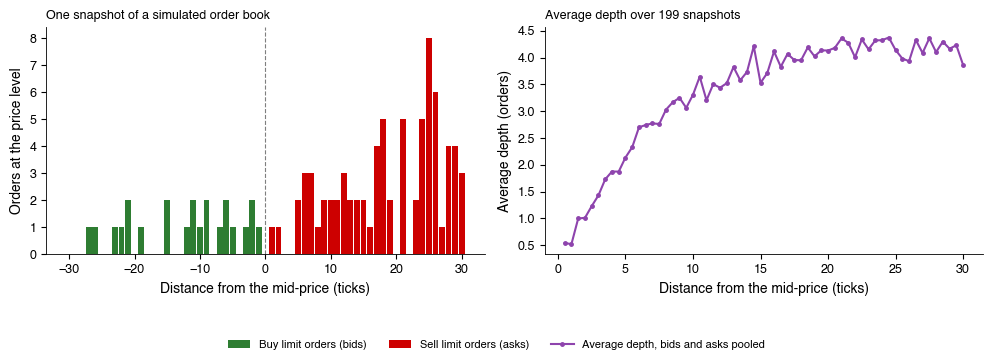

{'spread_mean': 3.860333333333333, 'spread_med': 3.0, 'spread_p90': 7.0, 'n_snaps': 199, 'depth1': 0.6877559377559378, 'depth10': 3.3380084630084634, 'depth25': 4.1659671034671035}


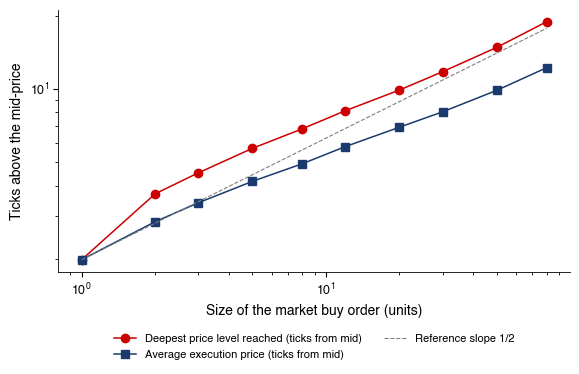

{'slope': 0.4714097650155769,
 'imp1': 1.9824120603015076,
 'imp80': 18.872093023255815,
 'cost1': 1.9824120603015076,
 'cost80': 12.213880813953487,
 'impslope_cost': 0.398958242208716}

In [5]:
ZI_PARAMS = {'n_events': 300000, 'L': 40, 'rate_limit': 0.1, 'rate_market': 0.5, 'rate_cancel': 0.02, 'seed': 7}


def zi_book():
    """Simularea registrului de ordine si functia de impact a unui ordin la piata."""
    path, snaps, _ = zi_simulate(**ZI_PARAMS)
    prof = pd.concat(snaps).groupby('rel')[['bid', 'ask']].mean()
    sizes = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80]
    imp, cost = {}, {}
    for q in sizes:
        last, vw = [], []
        for s in snaps:
            a = s[(s['rel'] > 0) & (s['ask'] > 0)]
            asks = list(zip(a['rel'], a['ask']))
            if sum(x for _, x in asks) < q:
                continue
            fills, vwap, _, _ = walk_book(asks, q)
            last.append(max(p for p, _ in fills))
            vw.append(vwap)
        imp[q], cost[q] = np.mean(last), np.mean(vw)
    slope = np.polyfit(np.log(sizes), np.log([imp[q] for q in sizes]), 1)[0]
    return dict(path=path, snaps=snaps, prof=prof, sizes=sizes, imp=imp, cost=cost, slope=slope)


def pooled_profile(p):
    """Adancimea medie la distanta k de mijloc: media dintre bid(-k) si ask(+k) (registrul este simetric in medie)."""
    ask = p['ask'][p.index > 0]
    bid = p['bid'][p.index < 0]
    bid.index = -bid.index
    return ((ask + bid.reindex(ask.index)) / 2).dropna()


def fig_lob(zb):
    snap = zb['snaps'][len(zb['snaps']) // 2]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    ax = axes[0]
    ax.bar(snap['rel'], snap['bid'], width=0.9, color=Forest, label='Buy limit orders (bids)')
    ax.bar(snap['rel'], snap['ask'], width=0.9, color=IDAred, label='Sell limit orders (asks)')
    ax.axvline(0, color=Gray, lw=0.8, ls='--')
    ax.set_xlabel('Distance from the mid-price (ticks)')
    ax.set_ylabel('Orders at the price level')
    ax.set_title('One snapshot of a simulated order book', fontsize=9, loc='left')
    ax = axes[1]
    p = zb['prof']
    pool = pooled_profile(p)
    ax.plot(pool.index, pool.values, color=Purple, lw=1.5, marker='o', ms=2.5, label='Average depth, bids and asks pooled')
    ax.set_xlabel('Distance from the mid-price (ticks)')
    ax.set_ylabel('Average depth (orders)')
    ax.set_title(f"Average depth over {len(zb['snaps'])} snapshots", fontsize=9, loc='left')
    h, l = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h + h2, l + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_lob_snapshot')
    sp = zb['path']['spread']
    return dict(spread_mean=float(sp.mean()), spread_med=float(sp.median()), spread_p90=float(sp.quantile(0.9)),
                n_snaps=len(zb['snaps']), depth1=float(pool.loc[0.5:1.5].mean()),
                depth10=float(pool.loc[9.5:10.5].mean()), depth25=float(pool.loc[24.5:25.5].mean()))


def fig_impact(zb):
    s = np.array(zb['sizes'])
    last = np.array([zb['imp'][q] for q in s])
    cost = np.array([zb['cost'][q] for q in s])
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    ax.loglog(s, last, 'o-', color=IDAred, label='Deepest price level reached (ticks from mid)')
    ax.loglog(s, cost, 's-', color=MainBlue, label='Average execution price (ticks from mid)')
    c = last[0] / s[0] ** 0.5
    ax.loglog(s, c * s ** 0.5, ls='--', color=Gray, lw=0.8, label='Reference slope 1/2')
    ax.set_xlabel('Size of the market buy order (units)')
    ax.set_ylabel('Ticks above the mid-price')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_walk_book')
    return dict(slope=float(zb['slope']), imp1=float(last[0]), imp80=float(last[-1]), cost1=float(cost[0]),
                cost80=float(cost[-1]), impslope_cost=float(np.polyfit(np.log(s), np.log(cost), 1)[0]))


zb = zi_book()
print(fig_lob(zb))
fig_impact(zb)

## 2. The Roll model (simulated)

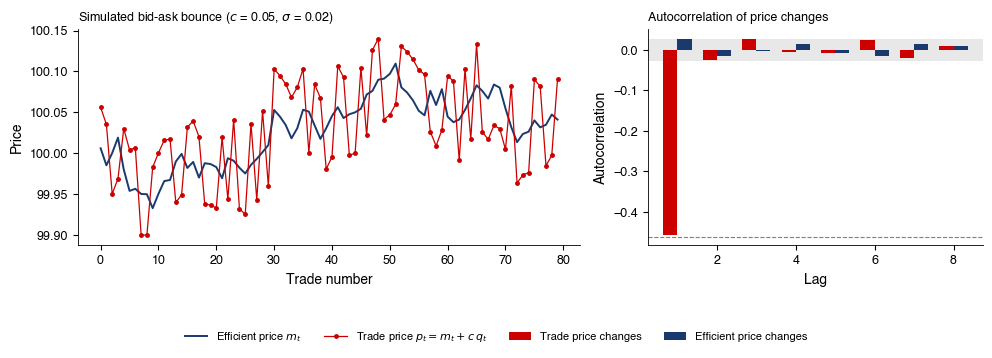

{'c': 0.05,
 'sigma': 0.02,
 'cov1': np.float64(-0.0024912833254543167),
 's_hat': np.float64(0.09982551428275872),
 's_true': 0.1,
 'var_dp': 0.00544197433993032,
 'var_theory': 0.005400000000000001,
 'rho1': -0.4577903477373279,
 'rho1_theory': -0.46296296296296297,
 'rho1_hat': -0.4577048396246077}

In [6]:
def roll_sim(n=5000, sigma=0.02, c=0.05, seed=SEED):
    """Pretul eficient m_t (mers aleator) si pretul tranzactiei p_t = m_t + c q_t, q_t = +1 / -1 (cumparare / vanzare)."""
    rng = np.random.default_rng(seed)
    m = 100 + np.cumsum(rng.normal(0, sigma, n))
    q = np.where(rng.random(n) < 0.5, 1, -1)
    p = m + c * q
    dp = np.diff(p)
    cov1 = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return m, q, p, dict(c=c, sigma=sigma, cov1=cov1, s_hat=2 * np.sqrt(-cov1), s_true=2 * c,
                         var_dp=float(np.var(dp)), var_theory=sigma ** 2 + 2 * c ** 2,
                         rho1=float(cov1 / np.var(dp)), rho1_theory=-c ** 2 / (sigma ** 2 + 2 * c ** 2))


def fig_roll():
    m, q, p, out = roll_sim()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    k = np.arange(80)
    ax.plot(k, m[:80], color=MainBlue, lw=1.4, label='Efficient price $m_t$')
    ax.plot(k, p[:80], color=IDAred, lw=0.9, marker='o', ms=2.5, label='Trade price $p_t = m_t + c\\,q_t$')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Price')
    ax.set_title('Simulated bid-ask bounce ($c$ = 0.05, $\\sigma$ = 0.02)', fontsize=9, loc='left')
    ax = axes[1]
    dp = np.diff(p)
    dm = np.diff(m)
    lags = np.arange(1, 9)
    acf_p = [np.corrcoef(dp[l:], dp[:-l])[0, 1] for l in lags]
    acf_m = [np.corrcoef(dm[l:], dm[:-l])[0, 1] for l in lags]
    ax.bar(lags - 0.18, acf_p, 0.36, color=IDAred, label='Trade price changes')
    ax.bar(lags + 0.18, acf_m, 0.36, color=MainBlue, label='Efficient price changes')
    b = 1.96 / np.sqrt(len(dp))
    ax.axhspan(-b, b, color='#DADADA', alpha=0.6, lw=0, zorder=0)
    ax.axhline(out['rho1_theory'], color=Gray, ls='--', lw=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation of price changes', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_roll_bounce')
    out['rho1_hat'] = float(acf_p[0])
    return out


fig_roll()

## 3. Intraday patterns of SPY and Bitcoin

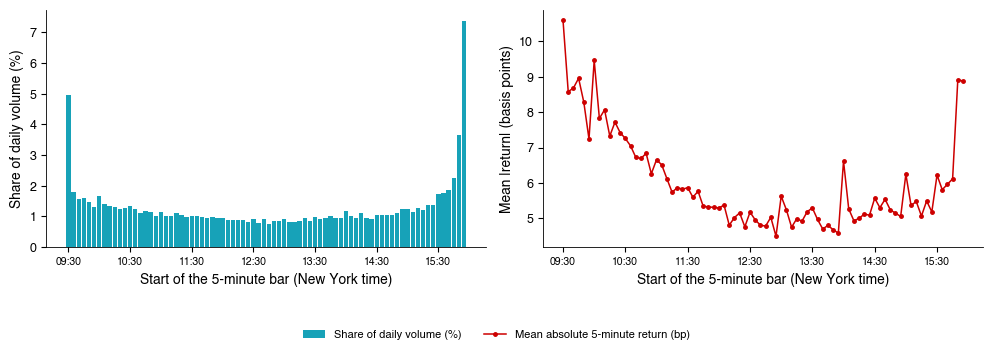

{'n_days': 1477,
 'first': '2020-10-12',
 'last': '2026-09-18',
 'share_open': 4.960268002147785,
 'share_close': 7.374423796775356,
 'share_last30': 18.630783223573474,
 'share_first30': 12.692625141838352,
 'share_mid': 0.909485230945039,
 'absr_open': 10.590414985574782,
 'absr_mid': 5.139410406383602,
 'absr_close': 8.879817050739323,
 'ratio_open_mid': 2.0606283888946777}

In [7]:
def spy_tod(s):
    """Profilul pe intervale de 5 minute: media |r| (pb), volumul median (milioane de actiuni), ponderea in volumul zilei."""
    x = s.dropna(subset=['r'])
    tod = x.groupby('tod').agg(absr=('r', lambda v: 1e4 * v.abs().mean()), vol=('volume', 'median'))
    share = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby(s['tod']).mean()
    tod['share'] = 100 * share
    return tod


def fig_spy_intraday(s):
    tod = spy_tod(s)
    x = np.arange(len(tod))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    ax.bar(x, tod['share'], color=Teal, width=0.85, label='Share of daily volume (%)')
    ax.set_ylabel('Share of daily volume (%)')
    ax = axes[1]
    ax.plot(x, tod['absr'], color=IDAred, marker='o', ms=2.5, label='Mean absolute 5-minute return (bp)')
    ax.set_ylabel('Mean |return| (basis points)')
    for a in axes:
        a.set_xticks(x[::12])
        a.set_xticklabels(tod.index[::12], rotation=0, fontsize=7.5)
        a.set_xlabel('Start of the 5-minute bar (New York time)')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_spy_intraday')
    mid = tod.loc['11:30':'14:00']
    return dict(n_days=int(s['date'].nunique()), first=s['date'].min().strftime('%Y-%m-%d'),
                last=s['date'].max().strftime('%Y-%m-%d'),
                share_open=float(tod['share'].iloc[0]), share_close=float(tod['share'].iloc[-1]),
                share_last30=float(tod['share'].iloc[-6:].sum()), share_first30=float(tod['share'].iloc[:6].sum()),
                share_mid=float(mid['share'].mean()), absr_open=float(tod['absr'].iloc[0]),
                absr_mid=float(mid['absr'].mean()), absr_close=float(tod['absr'].iloc[-1]),
                ratio_open_mid=float(tod['absr'].iloc[0] / mid['absr'].mean()))


spy = intraday_spy()
fig_spy_intraday(spy)

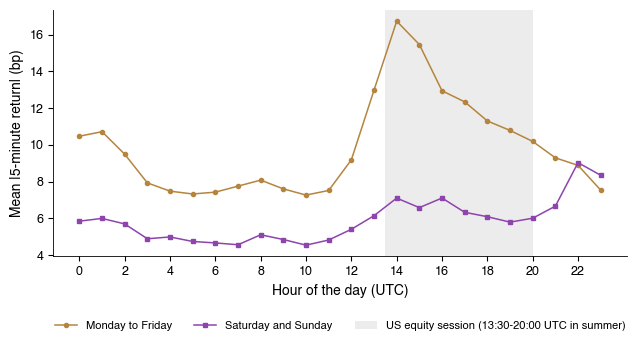

{'first': '2024-08-31',
 'last': '2026-09-18',
 'n_bars': 208596,
 'peak_hour': 14,
 'peak': 16.740055045021304,
 'low_hour': 10,
 'low': 7.270158900346827,
 'wd': 9.89904411876063,
 'we': 5.872959562630139,
 'ratio': 1.6855290783455443}

In [8]:
def btc_hours(b):
    x = b.dropna(subset=['r'])
    wk = x.index.dayofweek >= 5
    h = pd.DataFrame({'weekday': 1e4 * x.loc[~wk, 'r'].abs().groupby(x.index[~wk].hour).mean(),
                      'weekend': 1e4 * x.loc[wk, 'r'].abs().groupby(x.index[wk].hour).mean()})
    return h


def fig_btc_hours(b):
    h = btc_hours(b)
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    ax.plot(h.index, h['weekday'], color=Amber, marker='o', ms=3, label='Monday to Friday')
    ax.plot(h.index, h['weekend'], color=Purple, marker='s', ms=3, label='Saturday and Sunday')
    ax.axvspan(13.5, 20, color='#DADADA', alpha=0.5, lw=0, label='US equity session (13:30-20:00 UTC in summer)')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hour of the day (UTC)')
    ax.set_ylabel('Mean |5-minute return| (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.22)
    save_fig('ch10_btc_hours')
    x = b.dropna(subset=['r'])
    wk = x.index.dayofweek >= 5
    return dict(first=b.index.min().strftime('%Y-%m-%d'), last=b.index.max().strftime('%Y-%m-%d'),
                n_bars=int(len(x)), peak_hour=int(h['weekday'].idxmax()), peak=float(h['weekday'].max()),
                low_hour=int(h['weekday'].idxmin()), low=float(h['weekday'].min()),
                wd=float(1e4 * x.loc[~wk, 'r'].abs().mean()), we=float(1e4 * x.loc[wk, 'r'].abs().mean()),
                ratio=float(x.loc[~wk, 'r'].abs().mean() / x.loc[wk, 'r'].abs().mean()))


btc = intraday_btc()
fig_btc_hours(btc)

## 4. Spread estimators at two frequencies and across 25 assets

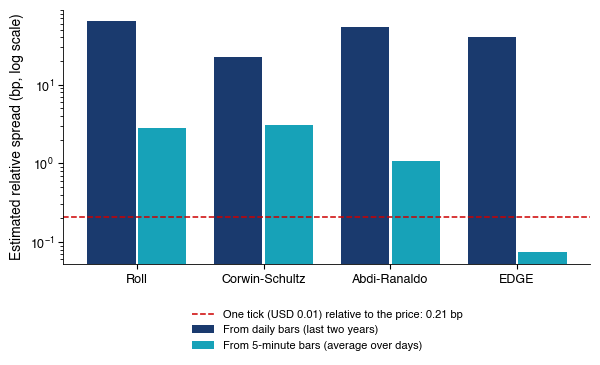

{'tick': 0.2065684865019977, 'roll5': 2.8178694948515814, 'cs5': 3.114235796578159, 'ar5': 1.0597709930490853, 'roll_d': 64.2538319726807, 'cs_d': 22.390237058522164, 'ar_d': 55.09545779283073, 'edge5': 0.0738712207707411, 'edge_d': 40.094405062870926, 'edge5_lo': 0.008646899372930499, 'edge5_hi': 0.1324141085444163, 'share_negcov': 0.5924170616113744, 'n_days': 1477}


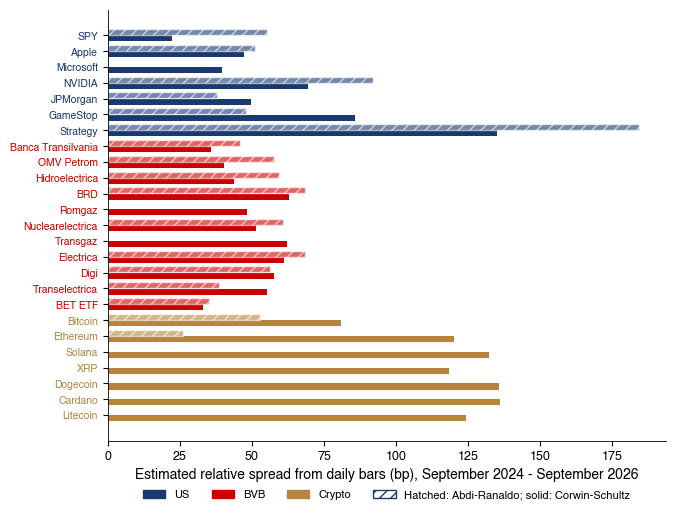

,roll,roll_cov,cs,edge,ar,ar_neg,n
SPY,64.253832,-0.00001,22.390237,40.094405,55.095458,False,501
AAPL,NaN,0.000013,47.130081,58.897625,51.054553,False,501
MSFT,NaN,0.000015,39.605492,-7.769576,0.0,True,501
NVDA,167.191409,-0.00007,69.442505,72.789731,91.977793,False,501
JPM,51.4506,-0.000007,49.641979,32.137955,37.814305,False,501
GME,109.139114,-0.00003,85.833468,17.89664,47.989338,False,501
MSTR,337.121177,-0.000284,134.88453,159.333039,184.272199,False,501
TLV,5.446375,-0.0,35.911981,32.632325,45.862954,False,493
SNP,35.188783,-0.000003,40.297933,54.639335,57.545941,False,493
H2O,NaN,0.000004,43.921976,53.085013,59.553925,False,493


In [9]:
def intraday_spreads(s):
    """Estimatorii Roll, Corwin-Schultz si Abdi-Ranaldo calculati pe barele de 5 minute ale fiecarei zile."""
    rows = {}
    for d, g in s.dropna(subset=['close', 'high', 'low']).groupby('date'):
        rs, cov = roll_spread(g['close'])
        rows[d] = dict(cov=cov, cs=cs_spread(g['high'], g['low']).mean(),
                       ar2=ar_terms(g['close'], g['high'], g['low']).mean(), price=g['close'].mean(),
                       edge=edge_spread(g['open'], g['high'], g['low'], g['close']),
                       var=np.var(np.diff(np.log(g['close'].values)), ddof=1))
    return pd.DataFrame(rows).T


def daily_spreads(key, start=START2):
    """Estimatorii din date zilnice pe ultimii doi ani (valori in puncte de baza)."""
    d = ohlc(key, start)
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return dict(roll=1e4 * rs if rs == rs else np.nan, roll_cov=float(cov), cs=1e4 * float(np.mean(cs)),
                edge=1e4 * edge_spread(d['open'], d['high'], d['low'], d['close']),
                ar=1e4 * float(np.sqrt(max(np.mean(ar2), 0))), ar_neg=bool(np.mean(ar2) <= 0), n=int(len(d)))


def spread_table():
    return {k: daily_spreads(k) for k in ASSETS}


def fig_spread_frequency(E, sp_daily):
    tick = 1e4 * (0.01 / E['price']).mean()
    roll5 = 1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0))
    cs5 = 1e4 * E['cs'].mean()
    ar5 = 1e4 * np.sqrt(max(E['ar2'].mean(), 0))
    edge5 = 1e4 * E['edge'].mean()                  # media estimarilor EDGE cu semn (nedeplasata)
    vals = {'Roll': (sp_daily['roll'], roll5), 'Corwin-Schultz': (sp_daily['cs'], cs5), 'Abdi-Ranaldo': (sp_daily['ar'], ar5),
            'EDGE': (sp_daily['edge'], edge5)}
    fig, ax = plt.subplots(figsize=(6.8, 3.3))
    x = np.arange(4)
    ax.bar(x - 0.2, [v[0] for v in vals.values()], 0.38, color=MainBlue, label='From daily bars (last two years)')
    ax.bar(x + 0.2, [v[1] for v in vals.values()], 0.38, color=Teal, label='From 5-minute bars (average over days)')
    ax.axhline(tick, color=IDAred, ls='--', lw=1.1, label=f'One tick (USD 0.01) relative to the price: {tick:.2f} bp')
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(list(vals))
    ax.set_ylabel('Estimated relative spread (bp, log scale)')
    legend_outside_bottom(ax, ncol=1, y=-0.14)
    save_fig('ch10_spread_frequency')
    rng = np.random.default_rng(SEED)
    ev = E['edge'].values
    eb = [1e4 * ev[rng.integers(0, len(ev), len(ev))].mean() for _ in range(B_BOOT)]
    return dict(tick=float(tick), roll5=float(roll5), cs5=float(cs5), ar5=float(ar5), roll_d=float(sp_daily['roll']),
                cs_d=float(sp_daily['cs']), ar_d=float(sp_daily['ar']), edge5=float(edge5), edge_d=float(sp_daily['edge']),
                edge5_lo=float(np.percentile(eb, 2.5)), edge5_hi=float(np.percentile(eb, 97.5)),
                share_negcov=float((E['cov'] < 0).mean()), n_days=int(len(E)))


def fig_spread_cross(T):
    keys = [k for g in ('US', 'BVB', 'Crypto') for k in GROUPS[g]]
    y = np.arange(len(keys))
    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    ax.barh(y + 0.2, [T[k]['cs'] for k in keys], 0.38, color=[GROUP_COL[ASSETS[k][2]] for k in keys],
            label='Corwin-Schultz')
    ax.barh(y - 0.2, [T[k]['ar'] for k in keys], 0.38, color=[GROUP_COL[ASSETS[k][2]] for k in keys], alpha=0.6,
            hatch='///', edgecolor='white', label='Abdi-Ranaldo')
    ax.set_yticks(y)
    ax.set_yticklabels([LABELS[k] for k in keys], fontsize=7.5)
    for t, k in zip(ax.get_yticklabels(), keys):
        t.set_color(GROUP_COL[ASSETS[k][2]])
    ax.invert_yaxis()
    ax.set_xlabel('Estimated relative spread from daily bars (bp), September 2024 - September 2026')
    from matplotlib.patches import Patch
    h = [Patch(color=MainBlue, label='US'), Patch(color=IDAred, label='BVB'), Patch(color=Amber, label='Crypto'),
         Patch(facecolor='white', edgecolor=MainBlue, hatch='///', label='Hatched: Abdi-Ranaldo; solid: Corwin-Schultz')]
    ax.legend(handles=h, loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=4, frameon=False)
    save_fig('ch10_spread_estimators')


E = intraday_spreads(spy)
T = spread_table()
print(fig_spread_frequency(E, T['SPY']))
fig_spread_cross(T)
pd.DataFrame(T).T.round(1)

### Small-sample properties of the Roll estimator (Harris, 1990)

- Share of days with a positive covariance and the pooled estimate, observed and simulated under the Roll model.

In [10]:
def roll_small_sample(E):
    """Covarianta Roll pe zi (77 de randamente de 5 minute): ponderea zilelor cu covarianta pozitiva, observata si
    simulata sub modelul Roll adevarat (spread de un pas de cotare; fara spread), si deplasarea din demediere."""
    n = 77
    v = E['var'].mean()
    c_tick = (0.01 / E['price']).mean() / 2
    out = dict(pos_obs=float((E['cov'] > 0).mean()), n_days=int(len(E)), sd_bar=float(1e4 * np.sqrt(v)),
               c_tick=float(1e4 * c_tick))
    for tag, c in [('tick', c_tick), ('zero', 0.0)]:
        sig = np.sqrt(v - 2 * c ** 2)
        cov = np.array([roll_mc(c, sig, T=n + 1, R=len(E), seed=SEED + b) for b in range(200)])
        pos = (cov > 0).mean(axis=1)                        # 200 de "esantioane" de lungimea selectiei reale
        pooled = 1e4 * 2 * np.sqrt(np.clip(-cov.mean(axis=1), 0, None))
        out[f'pos_{tag}'] = float(pos.mean())
        out[f'pos_{tag}_lo'], out[f'pos_{tag}_hi'] = (float(x) for x in np.percentile(pos, [2.5, 97.5]))
        out[f'roll_{tag}'] = float(pooled.mean())
        out[f'roll_{tag}_lo'], out[f'roll_{tag}_hi'] = (float(x) for x in np.percentile(pooled, [2.5, 97.5]))
    # corectia deplasarii: E[cov_hat] ~ g1 - (g0 + 2 g1) / n  =>  g1 ~ (cov_mediu + var_medie / n) / (1 - 2 / n)
    g1 = (E['cov'].mean() + v / n) / (1 - 2 / n)
    out['roll_corr'] = float(1e4 * 2 * np.sqrt(max(-g1, 0)))
    out['roll5'] = float(1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0)))
    return out


roll_small_sample(E)

{'pos_obs': 0.4075829383886256,
 'n_days': 1477,
 'sd_bar': 9.1583127862955,
 'c_tick': 0.10328424325099884,
 'pos_tick': 0.45316181448882875,
 'pos_tick_lo': 0.4299255247122546,
 'pos_tick_hi': 0.4808395396073122,
 'roll_tick': 2.0730377581893937,
 'roll_tick_lo': 1.5056679955636603,
 'roll_tick_hi': 2.53365546070691,
 'pos_zero': 0.4533243060257279,
 'pos_zero_lo': 0.4312796208530806,
 'pos_zero_hi': 0.4828199052132701,
 'roll_zero': 2.0625393126665523,
 'roll_zero_lo': 1.4988282803065303,
 'roll_zero_hi': 2.526258631145369,
 'roll_corr': 1.9180237793613462,
 'roll5': 2.8178694948515814}

## 5. Amihud illiquidity: cross-section and time series

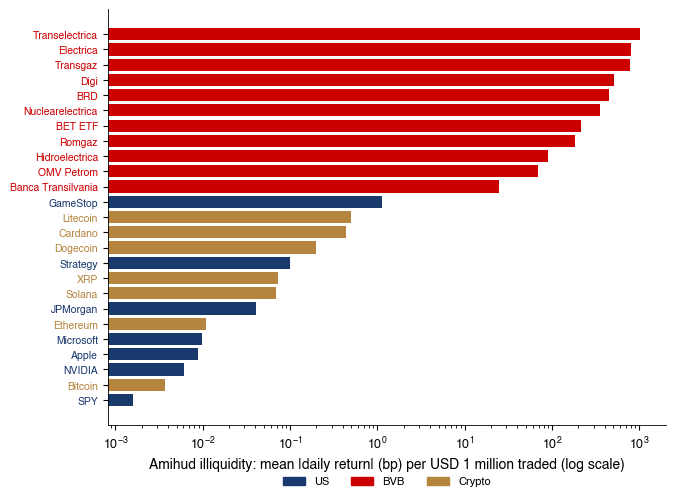

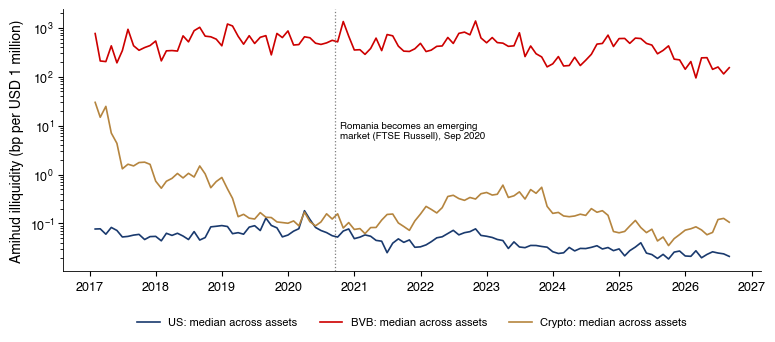

{'bvb_2017': 435.18275485986527, 'bvb_2026': 169.4213377540072, 'us_2017': 0.06236517942658145, 'us_2026': 0.02349180683278598, 'cr_2017': 7.604647281292688, 'cr_2026': 0.08915578655197696, 'ratio_bvb_us_2026': 7211.933035204295}


,illiq,dv_med,n
SPY,0.0016,40124.2235,500.0
AAPL,0.0088,11464.8278,500.0
MSFT,0.0097,10505.4882,500.0
NVDA,0.0060,30026.4606,500.0
JPM,0.0402,2360.7741,500.0
GME,1.1200,149.5000,500.0
MSTR,0.1003,3756.4297,500.0
TLV,24.7334,3.8998,492.0
SNP,68.3754,1.5246,492.0
H2O,88.5493,1.0588,492.0


In [11]:
def amihud_table(start=START2):
    out = {}
    for k in ASSETS:
        r = returns(k, start)
        dv = dollar_volume(k, start)
        out[k] = dict(illiq=amihud(r, dv), dv_med=float(dv.median() / 1e6), n=int(len(r)))
    return out


def fig_amihud(A):
    keys = sorted(ASSETS, key=lambda k: A[k]['illiq'])
    y = np.arange(len(keys))
    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    ax.barh(y, [A[k]['illiq'] for k in keys], color=[GROUP_COL[ASSETS[k][2]] for k in keys])
    ax.set_xscale('log')
    ax.set_yticks(y)
    ax.set_yticklabels([LABELS[k] for k in keys], fontsize=7.5)
    for t, k in zip(ax.get_yticklabels(), keys):
        t.set_color(GROUP_COL[ASSETS[k][2]])
    ax.set_xlabel('Amihud illiquidity: mean |daily return| (bp) per USD 1 million traded (log scale)')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COL.items()], loc='upper center',
              bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
    save_fig('ch10_amihud')


def monthly_illiq(keys, start=START10):
    """Iliciditatea Amihud lunara (pb la 1 milion USD) pentru fiecare activ; mediana pe grup."""
    cols = {}
    for k in keys:
        x = pd.concat([returns(k, start).rename('r'), dollar_volume(k, start).rename('dv')], axis=1, join='inner').dropna()
        x = x[x['dv'] > 0]
        cols[k] = (1e4 * x['r'].abs() / (x['dv'] / 1e6)).resample('ME').mean()
    return pd.DataFrame(cols)


def fig_amihud_time():
    med = {}
    for g in ('US', 'BVB', 'Crypto'):
        keys = [k for k in GROUPS[g] if k not in ('SPY', 'TVBETETF')]
        med[g] = monthly_illiq(keys).median(axis=1)
    med = pd.DataFrame(med).loc['2017-01':'2026-08']
    fig, ax = plt.subplots(figsize=(9, 3.4))
    for g, c in GROUP_COL.items():
        ax.plot(med.index, med[g], color=c, lw=1.2, label=f'{g}: median across assets')
    ax.set_yscale('log')
    ax.set_ylabel('Amihud illiquidity (bp per USD 1 million)')
    ax.axvline(pd.Timestamp('2020-09-15'), color=Gray, ls=':', lw=0.9)
    ax.text(pd.Timestamp('2020-10-15'), 8, 'Romania becomes an emerging\nmarket (FTSE Russell), Sep 2020',
            fontsize=7, color='black', va='center')
    legend_outside_bottom(ax, ncol=3, y=-0.14)
    save_fig('ch10_amihud_time')
    r = med.resample('YE').mean()
    return dict(bvb_2017=float(r['BVB'].iloc[0]), bvb_2026=float(r['BVB'].iloc[-1]),
                us_2017=float(r['US'].iloc[0]), us_2026=float(r['US'].iloc[-1]),
                cr_2017=float(r['Crypto'].iloc[0]), cr_2026=float(r['Crypto'].iloc[-1]),
                ratio_bvb_us_2026=float(r['BVB'].iloc[-1] / r['US'].iloc[-1]))


A = amihud_table()
fig_amihud(A)
print(fig_amihud_time())
pd.DataFrame(A).T.round(4)

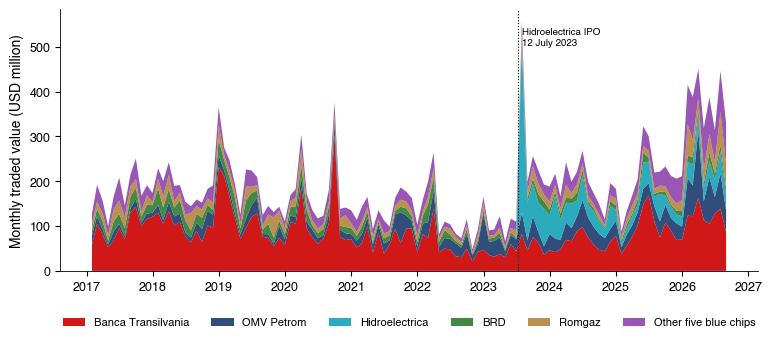

{'y2017': 2094.669234389605,
 'y2022': 1494.379079726255,
 'y2024': 2328.357395502786,
 'y2025': 2519.5879100678903,
 'tlv_share': 0.4405701086387218,
 'h2o_share': 0.13355825207990324}

In [12]:
def fig_bvb_turnover():
    keys = [k for k in GROUPS['BVB'] if k != 'TVBETETF']
    dv = pd.DataFrame({k: dollar_volume(k, START10) for k in keys}).fillna(0)
    m = dv.resample('ME').sum().loc['2017-01':'2026-08'] / 1e6
    top = ['TLV', 'SNP', 'H2O', 'BRD', 'SNG']
    fig, ax = plt.subplots(figsize=(9, 3.4))
    cols = [IDAred, MainBlue, Teal, Forest, Amber]
    ax.stackplot(m.index, [m[k] for k in top] + [m[[k for k in keys if k not in top]].sum(axis=1)],
                 colors=cols + [Purple], labels=[LABELS[k] for k in top] + ['Other five blue chips'], alpha=0.9)
    ax.set_ylabel('Monthly traded value (USD million)')
    ax.axvline(pd.Timestamp('2023-07-12'), color='black', lw=0.8, ls=':')
    ax.text(pd.Timestamp('2023-08-01'), ax.get_ylim()[1] * 0.93, 'Hidroelectrica IPO\n12 July 2023', fontsize=7, color='black', va='top')
    legend_outside_bottom(ax, ncol=6, y=-0.14)
    save_fig('ch10_bvb_turnover')
    y = m.sum(axis=1).resample('YE').sum()
    return dict(y2017=float(y.loc['2017'].iloc[0]), y2022=float(y.loc['2022'].iloc[0]), y2024=float(y.loc['2024'].iloc[0]),
                y2025=float(y.loc['2025'].iloc[0]), tlv_share=float(m['TLV'].loc['2025'].sum() / m.loc['2025'].sum().sum()),
                h2o_share=float(m['H2O'].loc['2025'].sum() / m.loc['2025'].sum().sum()))


fig_bvb_turnover()

### Price discovery: the BET ETF and the BET-TR index

- VECM with the cointegrating vector (1, -1); Hasbrouck information-share bounds; Gonzalo–Granger component share.

In [13]:
PD_START = '2024-09-19'
END_PD = '2026-09-18'


def bet_etf_pair(start=PD_START):
    """Logaritmul preturilor de inchidere: ETF-ul Patria-TVBETETF (zilele cu tranzactii) si indicele BET-TR, zile comune."""
    e = read_market('TVBETETF.RO')
    e = e[e['volume'] > 0]
    idx = read_market('BETTR.INDX')
    j = pd.concat([e['close'].rename('etf'), idx['close'].rename('idx')], axis=1, join='inner').dropna().loc[start:END_PD]
    return np.log(j)


def price_discovery_bet():
    from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order
    y = bet_etf_pair()
    p = int(select_order(y.values, maxlags=10, deterministic='ci').bic)
    jo = coint_johansen(y.values, 0, max(p, 1))
    r = price_discovery(y.values, max(p, 1))
    sd = float(100 * (y['etf'] - y['idx']).std())
    return dict(n=int(len(y)), p=max(p, 1), trace=float(jo.lr1[0]), cv=float(jo.cvt[0, 1]), trace1=float(jo.lr1[1]),
                cv1=float(jo.cvt[1, 1]), a_etf=float(r['alpha'][0]), a_idx=float(r['alpha'][1]), t_etf=float(r['t'][0]),
                t_idx=float(r['t'][1]), cs_etf=float(r['cs'][0]), cs_idx=float(r['cs'][1]), is_etf_lo=float(r['is_lo'][0]),
                is_etf_hi=float(r['is_hi'][0]), is_idx_lo=float(r['is_lo'][1]), is_idx_hi=float(r['is_hi'][1]),
                corr=r['corr'], sd_basis=sd, start=y.index[0].strftime('%Y-%m-%d'), end=y.index[-1].strftime('%Y-%m-%d'))


price_discovery_bet()

{'n': 495,
 'p': 1,
 'trace': 49.638335176116335,
 'cv': 15.4943,
 'trace1': 0.10180446807762619,
 'cv1': 3.8415,
 'a_etf': -0.1214459102853011,
 'a_idx': -0.03428253008476459,
 't_etf': -2.1099805086951555,
 't_idx': -0.6336008319602243,
 'cs_etf': -0.3933134534926351,
 'cs_idx': 1.393313453492635,
 'is_etf_lo': 0.022599987575940887,
 'is_etf_hi': 0.7493696794181902,
 'is_idx_lo': 0.2506303205818098,
 'is_idx_hi': 0.9774000124240595,
 'corr': 0.9310847008895238,
 'sd_basis': 0.842561262904749,
 'start': '2024-09-19',
 'end': '2026-09-18'}

## 6. Liquidity and volatility: SPY and the VIX

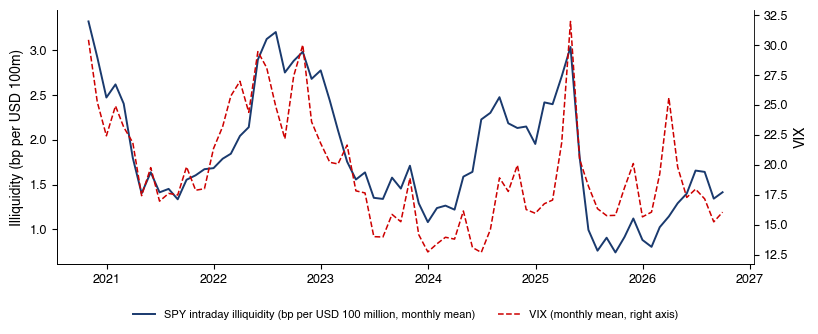

{'corr': 0.5849225297602763,
 'corr_m': 0.6902669158412825,
 'elast': 0.9544304059527832,
 'elast_se': 0.12116131927996482,
 'n': 1477,
 'mean': 1.8339556993864106,
 'y2020': 2.8588078413651576,
 'y2022': 2.598432009926328,
 'y2026': 1.3042643027859848,
 'apr2025': 3.0372145391281586}

In [14]:
def spy_illiq_daily(s):
    """Iliciditatea intrazilnica: media |r_5min| (pb) la 100 milioane USD tranzactionati, pe zi."""
    x = s.dropna(subset=['r', 'dv'])
    x = x[x['dv'] > 0]
    return (1e4 * x['r'].abs() / (x['dv'] / 1e8)).groupby(x['date']).mean().rename('illiq')


def fig_illiq_vix(s):
    ill = spy_illiq_daily(s)
    vix = read_market('VIX.INDX')['close'].rename('vix')
    j = pd.concat([ill, vix], axis=1, join='inner').dropna()
    m = j.resample('ME').mean()
    fig, ax = plt.subplots(figsize=(9, 3.3))
    l1 = ax.plot(m.index, m['illiq'], color=MainBlue, lw=1.4, label='SPY intraday illiquidity (bp per USD 100 million, monthly mean)')
    ax.set_ylabel('Illiquidity (bp per USD 100m)')
    ax2 = ax.twinx()
    ax2.spines['right'].set_visible(True)
    l2 = ax2.plot(m.index, m['vix'], color=IDAred, lw=1.1, ls='--', label='VIX (monthly mean, right axis)')
    ax2.set_ylabel('VIX')
    ax.legend(l1 + l2, [l.get_label() for l in l1 + l2], loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2,
              frameon=False)
    save_fig('ch10_spy_illiq_vix')
    X = sm.add_constant(np.log(j['vix']))
    fit = sm.OLS(np.log(j['illiq']), X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    return dict(corr=float(j.corr().iloc[0, 1]), corr_m=float(m.corr().iloc[0, 1]), elast=float(fit.params.iloc[1]),
                elast_se=float(fit.bse.iloc[1]), n=int(len(j)), mean=float(j['illiq'].mean()),
                y2020=float(ill.loc['2020'].mean()), y2022=float(ill.loc['2022'].mean()),
                y2026=float(ill.loc['2026'].mean()), apr2025=float(ill.loc['2025-04'].mean()))


fig_illiq_vix(spy)

## 7. Glosten–Milgrom and Kyle

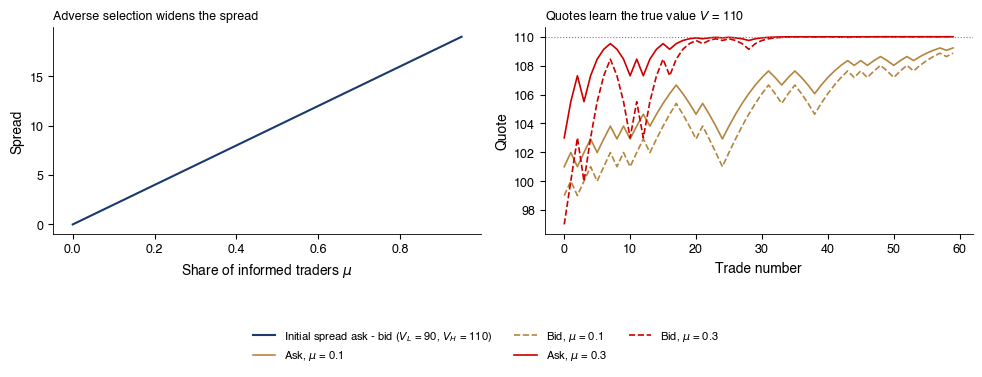

{'spread_01': 2.0, 'spread_03': 6.0, 't108_01': 48, 't108_03': 7}


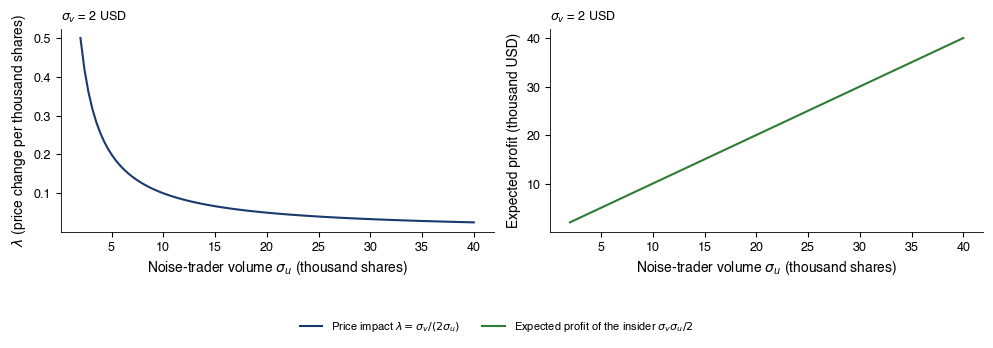

In [15]:
def fig_gm():
    mus = np.linspace(0, 0.95, 60)
    spreads = [gm_quotes(0.5, m, 90, 110)[0] - gm_quotes(0.5, m, 90, 110)[1] for m in mus]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    ax.plot(mus, spreads, color=MainBlue, lw=1.5, label='Initial spread ask - bid ($V_L$ = 90, $V_H$ = 110)')
    ax.set_xlabel('Share of informed traders $\\mu$')
    ax.set_ylabel('Spread')
    ax.set_title('Adverse selection widens the spread', fontsize=9, loc='left')
    ax = axes[1]
    sims = {}
    for mu, c in [(0.1, Amber), (0.3, IDAred)]:
        d = gm_simulate(mu, n=60, seed=3)
        sims[mu] = d
        ax.plot(d['t'], d['ask'], color=c, lw=1.2, label=f'Ask, $\\mu$ = {mu}')
        ax.plot(d['t'], d['bid'], color=c, lw=1.2, ls='--', label=f'Bid, $\\mu$ = {mu}')
    ax.axhline(110, color=Gray, lw=0.8, ls=':')
    ax.set_xlabel('Trade number')
    ax.set_ylabel('Quote')
    ax.set_title('Quotes learn the true value $V$ = 110', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_glosten_milgrom')
    first90 = {mu: int(next((i for i, r in d.iterrows() if r['bid'] > 108), -1)) for mu, d in sims.items()}
    return dict(spread_01=float(gm_quotes(0.5, 0.1, 90, 110)[0] - gm_quotes(0.5, 0.1, 90, 110)[1]),
                spread_03=float(gm_quotes(0.5, 0.3, 90, 110)[0] - gm_quotes(0.5, 0.3, 90, 110)[1]),
                t108_01=first90[0.1], t108_03=first90[0.3])


def fig_kyle():
    su = np.linspace(2, 40, 100)
    sv = 2.0
    lam = [kyle(sv, u)['lam'] for u in su]
    prof = [kyle(sv, u)['profit'] for u in su]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(su, lam, color=MainBlue, lw=1.5, label='Price impact $\\lambda = \\sigma_v / (2\\sigma_u)$')
    axes[0].set_xlabel('Noise-trader volume $\\sigma_u$ (thousand shares)')
    axes[0].set_ylabel('$\\lambda$ (price change per thousand shares)')
    axes[1].plot(su, prof, color=Forest, lw=1.5, label='Expected profit of the insider $\\sigma_v \\sigma_u / 2$')
    axes[1].set_xlabel('Noise-trader volume $\\sigma_u$ (thousand shares)')
    axes[1].set_ylabel('Expected profit (thousand USD)')
    for a in axes:
        a.set_title('$\\sigma_v$ = 2 USD', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch10_kyle')


print(fig_gm())
fig_kyle()

## 8. Volume and price moves; optimal execution

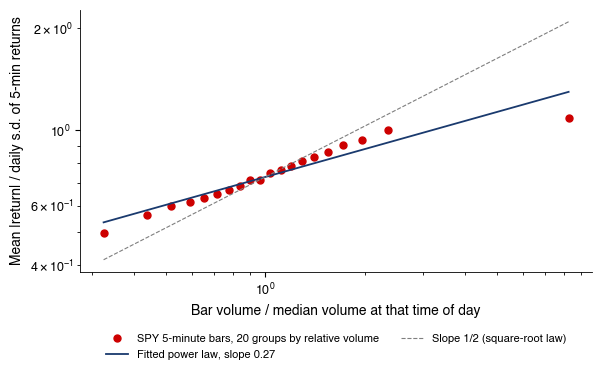

{'slope': 0.2741805378202134, 'n': 115052}

In [16]:
def sqrt_relation(s, nb=20):
    x = s.dropna(subset=['r', 'volume']).copy()
    x = x[x['volume'] > 0]
    x['part'] = x['volume'] / x.groupby('tod')['volume'].transform('median')
    x['z'] = x['r'].abs() / x.groupby('date')['r'].transform('std')
    bins = np.quantile(x['part'], np.linspace(0, 1, nb + 1))
    g = x.groupby(pd.cut(x['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean'))
    slope, icpt = np.polyfit(np.log(g['v']), np.log(g['z']), 1)
    return x, g, slope, icpt


def fig_sqrt(s):
    x, g, slope, icpt = sqrt_relation(s)
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    ax.loglog(g['v'], g['z'], 'o', color=IDAred, ms=5, label='SPY 5-minute bars, 20 groups by relative volume')
    vv = np.linspace(g['v'].min(), g['v'].max(), 50)
    ax.loglog(vv, np.exp(icpt) * vv ** slope, color=MainBlue, lw=1.3, label=f'Fitted power law, slope {slope:.2f}')
    ax.loglog(vv, np.exp(icpt) * vv ** 0.5, color=Gray, ls='--', lw=0.8, label='Slope 1/2 (square-root law)')
    ax.set_xlabel('Bar volume / median volume at that time of day')
    ax.set_ylabel('Mean |return| / daily s.d. of 5-min returns')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_sqrt_law')
    return dict(slope=float(slope), n=int(len(x)))


fig_sqrt(spy)

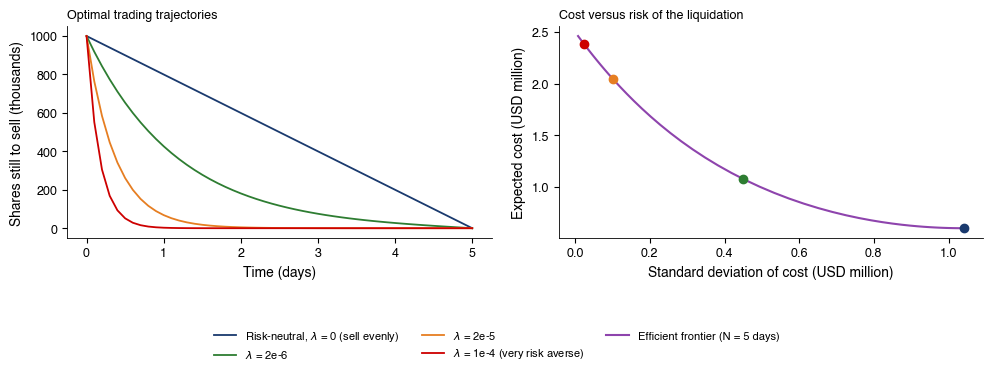

{'0': (600000, 1040673),
 '2e-06': (1078215, 449368),
 '2e-05': (2047390, 100616),
 '0.0001': (2384076, 23772)}

In [17]:
AC = {'X': 1000000.0, 'T': 5, 'N': 5, 'sigma': 0.95, 'eta': 2.5e-06, 'gamma': 2.5e-07}   # numerical example of Almgren and Chriss (2001)


def fig_ac():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    res = {}
    for lam, c, lab in [(0, MainBlue, 'Risk-neutral, $\\lambda$ = 0 (sell evenly)'), (2e-6, Forest, '$\\lambda$ = 2e-6'),
                        (2e-5, Orange, '$\\lambda$ = 2e-5'), (1e-4, IDAred, '$\\lambda$ = 1e-4 (very risk averse)')]:
        t, x, E, V = ac_trajectory(lam=lam, N=50, **{k: v for k, v in AC.items() if k != 'N'})
        ax.plot(t, x / 1e3, color=c, lw=1.3, label=lab)
        t5, x5, E5, V5 = ac_trajectory(lam=lam, **AC)
        res[lam] = dict(x=list(x5), E=E5, sd=np.sqrt(V5))
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Shares still to sell (thousands)')
    ax.set_title('Optimal trading trajectories', fontsize=9, loc='left')
    ax = axes[1]
    lams = np.logspace(-8, -3.5, 60)
    fr = ac_frontier(lams=lams, **AC)
    ax.plot(fr['sd'] / 1e6, fr['E'] / 1e6, color=Purple, lw=1.5, label='Efficient frontier (N = 5 days)')
    for lam, c in [(0, MainBlue), (2e-6, Forest), (2e-5, Orange), (1e-4, IDAred)]:
        ax.plot(res[lam]['sd'] / 1e6, res[lam]['E'] / 1e6, 'o', color=c, ms=6)
    ax.set_xlabel('Standard deviation of cost (USD million)')
    ax.set_ylabel('Expected cost (USD million)')
    ax.set_title('Cost versus risk of the liquidation', fontsize=9, loc='left')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_almgren_chriss')
    return {str(k): v for k, v in res.items()}


res = fig_ac()
{k: (round(v['E']), round(v['sd'])) for k, v in res.items()}

## 9. Stress episodes: 6 May 2010 and April 2025

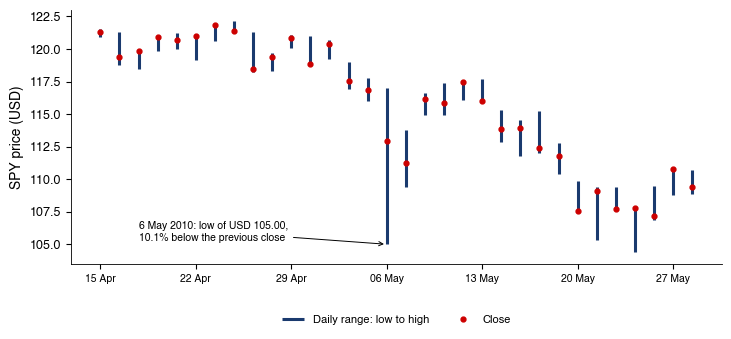

{'low': 105.0,
 'close': 112.942,
 'prev': 116.82,
 'drop_low': -0.10118130457113506,
 'drop_close': -0.03319637048450608,
 'vol_ratio': 2.970236287575119}

In [18]:
def fig_flash():
    d = read_market('SPY.US').loc['2010-04-15':'2010-05-28']
    prev = d['close'].shift(1)
    fig, ax = plt.subplots(figsize=(8.4, 3.3))
    x = np.arange(len(d))
    ax.vlines(x, d['low'], d['high'], color=MainBlue, lw=2.2, label='Daily range: low to high')
    ax.plot(x, d['close'], 'o', color=IDAred, ms=3.5, label='Close')
    i = d.index.get_loc(pd.Timestamp('2010-05-06'))
    ax.annotate('6 May 2010: low of USD 105.00,\n10.1% below the previous close', xy=(i, d['low'].iloc[i]),
                xytext=(i - 13, d['low'].iloc[i] + 0.3), fontsize=7.5, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
    ax.set_xticks(x[::5])
    ax.set_xticklabels([t.strftime('%d %b') for t in d.index[::5]], fontsize=7.5)
    ax.set_ylabel('SPY price (USD)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch10_flash_crash')
    r = d.loc['2010-05-06']
    return dict(low=float(r['low']), close=float(r['close']), prev=float(prev.loc['2010-05-06']),
                drop_low=float(r['low'] / prev.loc['2010-05-06'] - 1), drop_close=float(r['close'] / prev.loc['2010-05-06'] - 1),
                vol_ratio=float(r['volume'] / d['volume'].loc[:'2010-05-05'].median()))


fig_flash()

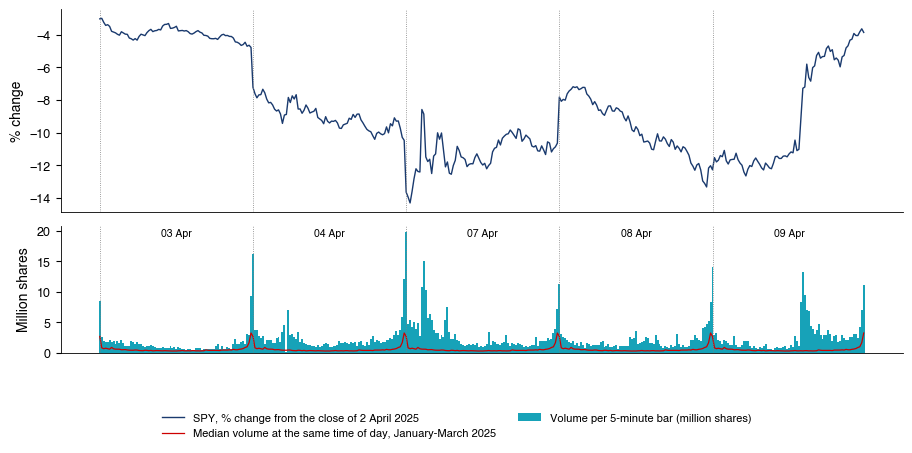

{'max_bar7': 4.276681403621829,
 'min_bar7': -2.9202520023476453,
 'range7': 8.586549629774076,
 'oc9': 10.011353720771087,
 'vol_ratio': 4.557156205161969,
 'rv7': 6.719062074797999,
 'rv_med': 0.6097448728318817}

In [19]:
def fig_april2025(s):
    days = ['2025-04-03', '2025-04-04', '2025-04-07', '2025-04-08', '2025-04-09']
    base = s.loc[s['date'] < pd.Timestamp(days[0])]
    prev_close = base['close'].dropna().iloc[-1]
    x = s.loc[s['date'].isin(pd.to_datetime(days))].copy()
    typical = s.loc['2025-01-01':'2025-03-31'].groupby('tod')['volume'].median()
    fig, axes = plt.subplots(2, 1, figsize=(9.2, 4.2), sharex=True, gridspec_kw={'height_ratios': [1.6, 1]})
    k = np.arange(len(x))
    axes[0].plot(k, 100 * (x['close'] / prev_close - 1), color=MainBlue, lw=1.0, label='SPY, % change from the close of 2 April 2025')
    axes[1].bar(k, x['volume'] / 1e6, color=Teal, width=1.0, label='Volume per 5-minute bar (million shares)')
    axes[1].plot(k, typical.reindex(x['tod']).values / 1e6, color=IDAred, lw=0.9,
                 label='Median volume at the same time of day, January-March 2025')
    for j, dd in enumerate(days):
        axes[1].text(78 * j + 39, axes[1].get_ylim()[1] * 0.92 if j == 0 else axes[1].get_ylim()[1] * 0.92,
                     pd.Timestamp(dd).strftime('%d %b'), ha='center', fontsize=7.5, color='black')
        for a in axes:
            a.axvline(78 * j, color=Gray, lw=0.6, ls=':')
    axes[0].set_ylabel('% change')
    axes[1].set_ylabel('Million shares')
    axes[1].set_xticks([])
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.03)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch10_april2025')
    d7 = s.loc[s['date'] == pd.Timestamp('2025-04-07')]
    d9 = s.loc[s['date'] == pd.Timestamp('2025-04-09')]
    rv = s.groupby('date')['r'].apply(lambda v: np.sqrt((v ** 2).sum()))
    return dict(max_bar7=float(100 * d7['r'].max()), min_bar7=float(100 * d7['r'].min()),
                range7=float(100 * (d7['high'].max() / d7['low'].min() - 1)),
                oc9=float(100 * (d9['close'].iloc[-1] / d9['open'].iloc[0] - 1)),
                vol_ratio=float(x['volume'].sum() / (typical.sum() * len(days))),
                rv7=float(100 * rv.loc['2025-04-07']), rv_med=float(100 * rv.median()))


fig_april2025(spy)